In [16]:
# Load the clean data sets
import pandas as pd
from pathlib import Path

clean_file = (
    Path.home() 
    /"Documents"
    /"Kazi_Academic"
    /"Projects"
    /"Aquaculture"
    /"fish-health-analytics"
    /"data"
    /"processed"
    /"barentswatch_lice_2025_clean.csv"
)
df = pd.read_csv(clean_file)
df. shape

/tmp/ipykernel_430912/719611192.py:16: DtypeWarning: Columns (0: weekly_lice_limit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(clean_file)


(55718, 22)

In [15]:
# Analysis of treatment data
import pandas as pd

treatment = pd.read_csv(
    "../data/raw/tiltak_mot_lakselus_2025.csv"
)

print("Shape:", treatment.shape)
print("\nColumns:")
print(treatment.columns.tolist())

Shape: (7875, 20)

Columns:
['Uke', 'År', 'Lokalitetsnummer', 'Lokalitetsnavn', 'Tiltak', 'Type behandling', 'Virkestoff', 'ArtsId', 'Rensefisk', 'Antall', 'Omfang', 'Kommunenummer', 'Kommune', 'Fylkesnummer', 'Fylke', 'Lat', 'Lon', 'ProduksjonsområdeId', 'Produksjonsområde', 'Antall merder']


In [2]:
# Look at the first few treatment records
display(treatment.head())

# See the main treatment categories
print("\nTiltak:")
print(treatment["Tiltak"].value_counts(dropna=False))

print("\nType behandling:")
print(treatment["Type behandling"].value_counts(dropna=False))

# Check whether the same locality appears more than once in the same week
locality_week_counts = (
    treatment
    .groupby(["År", "Uke", "Lokalitetsnummer"])
    .size()
)

print("\nUnique locality-weeks:", len(locality_week_counts))
print("Locality-weeks with more than one row:",
      (locality_week_counts > 1).sum())

print("Maximum rows for one locality-week:",
      locality_week_counts.max())

,Uke,År,Lokalitetsnummer,Lokalitetsnavn,Tiltak,Type behandling,Virkestoff,ArtsId,Rensefisk,Antall,Omfang,Kommunenummer,Kommune,Fylkesnummer,Fylke,Lat,Lon,ProduksjonsområdeId,Produksjonsområde,Antall merder
0,52,2025,13209,Bognøy,medikamentell,badebehandling,Azamethiphos,NaN,NaN,NaN,deler av lokaliteten,4631,ALVER,46,Vestland,60.604416,5.075833,4,Nordhordaland til Stadt,2.0
1,52,2025,13209,Bognøy,ikke-medikamentell,ferskvannsbehandling,NaN,NaN,NaN,NaN,deler av lokaliteten,4631,ALVER,46,Vestland,60.604416,5.075833,4,Nordhordaland til Stadt,1.0
2,52,2025,13209,Bognøy,ikke-medikamentell,termisk behandling,NaN,NaN,NaN,NaN,deler av lokaliteten,4631,ALVER,46,Vestland,60.604416,5.075833,4,Nordhordaland til Stadt,1.0
3,52,2025,10256,Bondøya,ikke-medikamentell,mekanisk behandling,NaN,NaN,NaN,NaN,deler av lokaliteten,5060,NÆRØYSUND,50,Trøndelag,64.816800,10.742700,7,Nord-Trøndelag med Bindal,6.0
4,52,2025,13841,Brunsvik,ikke-medikamentell,mekanisk behandling,NaN,NaN,NaN,NaN,hele lokaliteten,4602,KINN,46,Vestland,61.910183,5.290850,4,Nordhordaland til Stadt,NaN



Tiltak:
Tiltak
ikke-medikamentell    7232
medikamentell          643
Name: count, dtype: int64

Type behandling:
Type behandling
mekanisk behandling     3737
termisk behandling      1891
annen behandling         819
ferskvannsbehandling     785
fôrbehandling            429
badebehandling           214
Name: count, dtype: int64

Unique locality-weeks: 4521
Locality-weeks with more than one row: 1444
Maximum rows for one locality-week: 14


In [4]:
# Inspect the locality-week with 14 rows
# Find the locality-week with the most treatment rows
max_group = locality_week_counts.idxmax()
year, week, locality_id = max_group
print("Year:", year)
print("Week:", week)
print("Locality ID:", locality_id)

Year: 2025
Week: 22
Locality ID: 10828


In [11]:
# Select that locality-week
example = treatment[(treatment["År"] == year ) & (treatment["Uke"] == week ) & (treatment["Lokalitetsnummer"] == locality_id )]


In [10]:

# Show selected columns
example[
    [
        "Lokalitetsnavn",
        "Tiltak",
        "Type behandling",
        "Virkestoff",
        "Omfang",
        "Antall merder"
    ]
]

,Lokalitetsnavn,Tiltak,Type behandling,Virkestoff,Omfang,Antall merder
5914,Kleppenes N,ikke-medikamentell,ferskvannsbehandling,NaN,deler av lokaliteten,1.0
5915,Kleppenes N,ikke-medikamentell,mekanisk behandling,NaN,deler av lokaliteten,1.0
5916,Kleppenes N,ikke-medikamentell,ferskvannsbehandling,NaN,deler av lokaliteten,1.0
5917,Kleppenes N,ikke-medikamentell,mekanisk behandling,NaN,deler av lokaliteten,1.0
5918,Kleppenes N,ikke-medikamentell,ferskvannsbehandling,NaN,deler av lokaliteten,1.0
5919,Kleppenes N,ikke-medikamentell,mekanisk behandling,NaN,deler av lokaliteten,1.0
5920,Kleppenes N,ikke-medikamentell,ferskvannsbehandling,NaN,deler av lokaliteten,1.0
5921,Kleppenes N,ikke-medikamentell,mekanisk behandling,NaN,deler av lokaliteten,1.0
5922,Kleppenes N,ikke-medikamentell,ferskvannsbehandling,NaN,deler av lokaliteten,1.0
5923,Kleppenes N,ikke-medikamentell,mekanisk behandling,NaN,deler av lokaliteten,1.0


In [12]:
# Make a clean weekly treatment table
# Rename the most important columns
treatment_clean = treatment.rename(columns={
    "Uke": "week",
    "År": "year",
    "Lokalitetsnummer": "locality_id",
    "Lokalitetsnavn": "locality_name",
    "Tiltak": "treatment_class",
    "Type behandling": "treatment_type"
}).copy()

# Create True/False flags for each treatment type
treatment_clean["mechanical"] = (
    treatment_clean["treatment_type"] == "mekanisk behandling"
)

treatment_clean["thermal"] = (
    treatment_clean["treatment_type"] == "termisk behandling"
)

treatment_clean["freshwater"] = (
    treatment_clean["treatment_type"] == "ferskvannsbehandling"
)

treatment_clean["feed"] = (
    treatment_clean["treatment_type"] == "fôrbehandling"
)

treatment_clean["bath"] = (
    treatment_clean["treatment_type"] == "badebehandling"
)

treatment_clean["other"] = (
    treatment_clean["treatment_type"] == "annen behandling"
)

# Collapse to one row per locality-week
treatment_weekly = treatment_clean.groupby(
    ["year", "week", "locality_id", "locality_name"],
    as_index=False
).agg(
    treatment_records=("treatment_type", "size"),
    mechanical=("mechanical", "max"),
    thermal=("thermal", "max"),
    freshwater=("freshwater", "max"),
    feed=("feed", "max"),
    bath=("bath", "max"),
    other=("other", "max")
)

treatment_weekly.head()

,year,week,locality_id,locality_name,treatment_records,mechanical,thermal,freshwater,feed,bath,other
0,2025,1,10136,Onarøy,2,False,True,True,False,False,False
1,2025,1,10828,Kleppenes N,2,False,False,False,False,True,False
2,2025,1,10837,Kraken,2,False,True,False,True,False,False
3,2025,1,11318,Hallvardøy,1,False,False,False,False,True,False
4,2025,1,11332,Myrlandshaug,1,False,True,False,False,False,False


In [13]:
# ne-row-per-locality-week treatment table.
# Rename important columns
treatment_clean = treatment.rename(columns={
    "Uke": "week",
    "År": "year",
    "Lokalitetsnummer": "locality_id",
    "Lokalitetsnavn": "locality_name",
    "Tiltak": "treatment_class",
    "Type behandling": "treatment_type"
}).copy()

# Create True/False columns for each treatment type
treatment_clean["mechanical"] = treatment_clean["treatment_type"] == "mekanisk behandling"
treatment_clean["thermal"] = treatment_clean["treatment_type"] == "termisk behandling"
treatment_clean["freshwater"] = treatment_clean["treatment_type"] == "ferskvannsbehandling"
treatment_clean["feed"] = treatment_clean["treatment_type"] == "fôrbehandling"
treatment_clean["bath"] = treatment_clean["treatment_type"] == "badebehandling"
treatment_clean["other"] = treatment_clean["treatment_type"] == "annen behandling"

# Combine multiple treatment rows into one locality-week
treatment_weekly = treatment_clean.groupby(
    ["year", "week", "locality_id", "locality_name"],
    as_index=False
).agg(
    treatment_records=("treatment_type", "size"),
    mechanical=("mechanical", "max"),
    thermal=("thermal", "max"),
    freshwater=("freshwater", "max"),
    feed=("feed", "max"),
    bath=("bath", "max"),
    other=("other", "max")
)

print("Shape:", treatment_weekly.shape)

treatment_weekly.head()

Shape: (4521, 11)


,year,week,locality_id,locality_name,treatment_records,mechanical,thermal,freshwater,feed,bath,other
0,2025,1,10136,Onarøy,2,False,True,True,False,False,False
1,2025,1,10828,Kleppenes N,2,False,False,False,False,True,False
2,2025,1,10837,Kraken,2,False,True,False,True,False,False
3,2025,1,11318,Hallvardøy,1,False,False,False,False,True,False
4,2025,1,11332,Myrlandshaug,1,False,True,False,False,False,False


In [22]:
# Before merging this with the lice dataset, we should check one important thing: are the merge keys unique in both tables?
lice_duplicates = df.duplicated(
    subset=["year", "week", "locality_id"]
).sum()

treatment_duplicates = treatment_weekly.duplicated(
    subset=["year", "week", "locality_id"]
).sum()

print("Duplicate locality-weeks in lice data:", lice_duplicates)
print("Duplicate locality-weeks in treatment data:", treatment_duplicates)

Duplicate locality-weeks in lice data: 0
Duplicate locality-weeks in treatment data: 0


In [23]:
# Merge treatment data with lice data
# Columns we want to add from the treatment table
treatment_info = treatment_weekly[
    [
        "year",
        "week",
        "locality_id",
        "treatment_records",
        "mechanical",
        "thermal",
        "freshwater",
        "feed",
        "bath",
        "other"
    ]
]

# Merge treatment information onto the weekly lice data
combined = df.merge(
    treatment_info,
    on=["year", "week", "locality_id"],
    how="left",
    validate="one_to_one",
    indicator=True
)

print("Combined shape:", combined.shape)
print("\nMerge result:")
print(combined["_merge"].value_counts())

Combined shape: (55718, 30)

Merge result:
_merge
left_only     51197
both           4521
right_only        0
Name: count, dtype: int64


In [24]:
# Do those treatment weeks actually have a lice measurement?
# Mark whether a treatment was reported that week
combined["any_treatment"] = combined["_merge"] == "both"

# Look only at treatment weeks
treatment_weeks = combined[
    combined["any_treatment"]
].copy()

print("Treatment locality-weeks:", len(treatment_weeks))

print(
    "Treatment weeks with lice measurement:",
    treatment_weeks["adult_female_lice"].notna().sum()
)

print(
    "Treatment weeks without lice measurement:",
    treatment_weeks["adult_female_lice"].isna().sum()
)

Treatment locality-weeks: 4521
Treatment weeks with lice measurement: 4497
Treatment weeks without lice measurement: 24


In [25]:
# Sort locality observations in time order
combined = combined.sort_values(
    ["locality_id", "year", "week"]
).copy()

# Was there also a treatment in the previous week?
combined["treatment_previous_week"] = (
    combined.groupby("locality_id")["any_treatment"]
    .shift(1)
    .fillna(False)
)

# Was there also a treatment in the following week?
combined["treatment_next_week"] = (
    combined.groupby("locality_id")["any_treatment"]
    .shift(-1)
    .fillna(False)
)

# Look only at treatment weeks
treatment_weeks = combined[combined["any_treatment"]].copy()

print(
    "Treatment weeks:",
    len(treatment_weeks)
)

print(
    "Also treated previous week:",
    treatment_weeks["treatment_previous_week"].sum()
)

print(
    "Also treated following week:",
    treatment_weeks["treatment_next_week"].sum()
)

Treatment weeks: 4521
Also treated previous week: 1446
Also treated following week: 1446


In [26]:
# Sort observations in time order
combined = combined.sort_values(
    ["locality_id", "year", "week"]
).copy()

# Previous row information within each locality/year
previous_week = combined.groupby(
    ["locality_id", "year"]
)["week"].shift(1)

previous_treatment = combined.groupby(
    ["locality_id", "year"]
)["any_treatment"].shift(1).fillna(False)

# Following row information
next_week = combined.groupby(
    ["locality_id", "year"]
)["week"].shift(-1)

next_treatment = combined.groupby(
    ["locality_id", "year"]
)["any_treatment"].shift(-1).fillna(False)

# True only if treatment occurred in the actual previous/next calendar week
combined["treatment_previous_week"] = (
    previous_treatment
    & ((combined["week"] - previous_week) == 1)
)

combined["treatment_next_week"] = (
    next_treatment
    & ((next_week - combined["week"]) == 1)
)

# Treatment weeks only
treatment_weeks = combined[combined["any_treatment"]].copy()

print("Treatment weeks:", len(treatment_weeks))
print(
    "Also treated previous calendar week:",
    treatment_weeks["treatment_previous_week"].sum()
)
print(
    "Also treated following calendar week:",
    treatment_weeks["treatment_next_week"].sum()
)

Treatment weeks: 4521
Also treated previous calendar week: 1446
Also treated following calendar week: 1446


# many treatments occur in multi-week sequences, 
* so for effectiveness we should analyze treatment episodes, not treat every treatment week as an independent event.

* Next we will assign an episode number within each locality.

In [27]:
# episode number within each locality.
#Keep only treatments week
episodes = combined[combined["any_treatment"]].copy()

In [28]:
# Sort by locality and week
episodes = episodes.sort_values(["locality_id", "year", "week"])

In [29]:
# Find the gap between treatment weeks
episodes["week_gap"] = (episodes.groupby(["locality_id", "year"])["week"].diff())

In [30]:
# A new episode starts when:
# - it is the first treatment for that locality, or
# - the previous treatment was more than 1 week ago
episodes["new_episode"] = (
    episodes["week_gap"].isna()
    | (episodes["week_gap"] > 1)
)

# Give each episode an ID
episodes["episode_id"] = (
    episodes.groupby(["locality_id", "year"])["new_episode"]
    .cumsum()
)

print("Treatment weeks:", len(episodes))

episode_count = (
    episodes[
        ["locality_id", "year", "episode_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

print("Treatment episodes:", episode_count)

Treatment weeks: 4521
Treatment episodes: 3075


In [32]:
# how long did treatment episodes last?
episode_summary = episodes.groupby(
    ["locality_id", "year", "episode_id"],
    as_index=False
).agg(
    locality_name=("locality_name", "first"),
    start_week=("week", "min"),
    end_week= ("week", "max"),
    treatment_weeks=("week", "count")
)




print("Number of episodes:", len(episode_summary))
print("\nEpisode length:")
print(
    episode_summary["treatment_weeks"]
    .value_counts()
    .sort_index()
)
    
                                   

Number of episodes: 3075

Episode length:
treatment_weeks
1     2054
2      767
3      170
4       43
5       20
6       13
7        3
8        1
10       1
11       2
12       1
Name: count, dtype: int64


In [33]:
episode_summary["pre_week"] = (
    episode_summary["start_week"] - 1
)

episode_summary["post_week"] = (
    episode_summary["end_week"] + 1
)

episode_summary[
    [
        "locality_name",
        "start_week",
        "end_week",
        "pre_week",
        "post_week",
        "treatment_weeks"
    ]
].head(10)

,locality_name,start_week,end_week,pre_week,post_week,treatment_weeks
0,Tuholmane Ø,3,3,2,4,1
1,Tuholmane Ø,13,13,12,14,1
2,Tuholmane Ø,21,21,20,22,1
3,Kviksholmen,7,7,6,8,1
4,Kviksholmen,17,17,16,18,1
5,Kviksholmen,51,51,50,52,1
6,Ospøy Ø,42,43,41,44,2
7,Ospøy Ø,49,49,48,50,1
8,Tobbeholmane,2,3,1,4,2
9,Tobbeholmane,6,7,5,8,2


# bring the actual lice values for those pre_week and post_week numbers into episode_summary.


In [34]:
# Make a small lookup table containing the weekly lice measurements
lice_lookup = df[
    ["year", "week", "locality_id", "adult_female_lice"]
].copy()

In [35]:
# ----- PRE-TREATMENT LICE -----

pre_lice = lice_lookup.rename(columns={
    "week": "pre_week",
    "adult_female_lice": "pre_lice"
})

episode_summary = episode_summary.merge(
    pre_lice,
    on=["year", "locality_id", "pre_week"],
    how="left"
)

In [36]:
# ----- POST-TREATMENT LICE -----

post_lice = lice_lookup.rename(columns={
    "week": "post_week",
    "adult_female_lice": "post_lice"
})

episode_summary = episode_summary.merge(
    post_lice,
    on=["year", "locality_id", "post_week"],
    how="left"
)

In [37]:
# Look at the result
episode_summary[
    [
        "locality_name",
        "start_week",
        "end_week",
        "pre_week",
        "pre_lice",
        "post_week",
        "post_lice"
    ]
].head(10)

,locality_name,start_week,end_week,pre_week,pre_lice,post_week,post_lice
0,Tuholmane Ø,3,3,2,0.46,4,0.11
1,Tuholmane Ø,13,13,12,0.25,14,0.01
2,Tuholmane Ø,21,21,20,0.16,22,0.09
3,Kviksholmen,7,7,6,0.35,8,0.03
4,Kviksholmen,17,17,16,0.17,18,0.08
5,Kviksholmen,51,51,50,0.20,52,0.03
6,Ospøy Ø,42,43,41,0.30,44,0.30
7,Ospøy Ø,49,49,48,0.30,50,0.05
8,Tobbeholmane,2,3,1,0.37,4,0.16
9,Tobbeholmane,6,7,5,0.23,8,0.01


In [38]:
# Keep only episodes with both pre- and post-treatment lice measurements
valid_effectiveness = episode_summary[
    episode_summary["pre_lice"].notna()
    & episode_summary["post_lice"].notna()
].copy()

print("Total treatment episodes:", len(episode_summary))
print("Episodes with valid pre/post lice:", len(valid_effectiveness))
print(
    "Episodes missing pre or post lice:",
    len(episode_summary) - len(valid_effectiveness)
)

Total treatment episodes: 3075
Episodes with valid pre/post lice: 2925
Episodes missing pre or post lice: 150


# calculate the change in lice

In [39]:
# Change in adult female lice after treatment
valid_effectiveness["lice_change"] = (
    valid_effectiveness["post_lice"]
    - valid_effectiveness["pre_lice"]
)

# Show a few examples
valid_effectiveness[
    [
        "locality_name",
        "pre_lice",
        "post_lice",
        "lice_change"
    ]
].head(10)

,locality_name,pre_lice,post_lice,lice_change
0,Tuholmane Ø,0.46,0.11,-0.35
1,Tuholmane Ø,0.25,0.01,-0.24
2,Tuholmane Ø,0.16,0.09,-0.07
3,Kviksholmen,0.35,0.03,-0.32
4,Kviksholmen,0.17,0.08,-0.09
5,Kviksholmen,0.20,0.03,-0.17
6,Ospøy Ø,0.30,0.30,0.00
7,Ospøy Ø,0.30,0.05,-0.25
8,Tobbeholmane,0.37,0.16,-0.21
9,Tobbeholmane,0.23,0.01,-0.22


In [40]:
# Among the 2,925 usable treatment episodes, how many showed a decrease, no change, or increase in adult female lice in the first week after the episode?
# Start by calling every episode "No change"
valid_effectiveness["outcome"] = "No change"

# If lice_change is below 0, call it a decrease
valid_effectiveness.loc[
    valid_effectiveness["lice_change"] < 0,
    "outcome"
] = "Decrease"

# If lice_change is above 0, call it an increase
valid_effectiveness.loc[
    valid_effectiveness["lice_change"] > 0,
    "outcome"
] = "Increase"


# Count each outcome
outcome_counts = valid_effectiveness["outcome"].value_counts()

# Convert counts to percentages
outcome_percent = (
    valid_effectiveness["outcome"]
    .value_counts(normalize=True)
    * 100
)

# Put counts and percentages together
outcome_summary = pd.DataFrame({
    "count": outcome_counts,
    "percent": outcome_percent
})

outcome_summary

,count,percent
outcome,,
Decrease,2180,74.529915
Increase,634,21.675214
No change,111,3.794872


# How large was the change?

In [41]:
print(
    "Mean pre-treatment lice:",
    valid_effectiveness["pre_lice"].mean()
)

print(
    "Mean post-treatment lice:",
    valid_effectiveness["post_lice"].mean()
)

print(
    "Mean lice change:",
    valid_effectiveness["lice_change"].mean()
)

print()

print(
    "Median pre-treatment lice:",
    valid_effectiveness["pre_lice"].median()
)

print(
    "Median post-treatment lice:",
    valid_effectiveness["post_lice"].median()
)

print(
    "Median lice change:",
    valid_effectiveness["lice_change"].median()
)

Mean pre-treatment lice: 0.399374358974359
Mean post-treatment lice: 0.20016410256410258
Mean lice change: -0.1992102564102564

Median pre-treatment lice: 0.34
Median post-treatment lice: 0.14
Median lice change: -0.13


# do different treatment methods behave differently?

* Before comparing mechanical vs thermal vs freshwater, 
* we need to know which episodes used one treatment type and 
* which used multiple treatment types.

In [43]:
# Summarize treatment methods across each complete treatment episode
episode_methods = episodes.groupby(
    ["locality_id", "year", "episode_id"],
    as_index=False
).agg(
    mechanical=("mechanical", "max"),
    thermal=("thermal", "max"),
    freshwater=("freshwater", "max"),
    feed=("feed", "max"),
    bath=("bath", "max"),
    other=("other", "max")
)

# Count how many different treatment types occurred in each episode
method_columns = [
    "mechanical",
    "thermal",
    "freshwater",
    "feed",
    "bath",
    "other"
]

episode_methods["number_of_methods"] = (
    episode_methods[method_columns].sum(axis=1)
)

# Show how many episodes used 1, 2, 3... methods
episode_methods["number_of_methods"].value_counts().sort_index()

number_of_methods
1    2456
2     581
3      38
Name: count, dtype: int64

# identify the method used in single-method episodes

In [44]:
# Add treatment-method information to our effectiveness table
effectiveness_with_methods = valid_effectiveness.merge(
    episode_methods,
    on=["locality_id", "year", "episode_id"],
    how="left"
)

# Keep only episodes where exactly one treatment method was used
single_method = effectiveness_with_methods[
    effectiveness_with_methods["number_of_methods"] == 1
].copy()

# These are the possible treatment-method columns
method_columns = [
    "mechanical",
    "thermal",
    "freshwater",
    "feed",
    "bath",
    "other"
]

# Because exactly one column is True,
# idxmax() returns the name of that treatment method
single_method["treatment_method"] = (
    single_method[method_columns]
    .idxmax(axis=1)
)

print("Usable single-method episodes:", len(single_method))

print("\nEpisodes by treatment method:")
print(
    single_method["treatment_method"]
    .value_counts()
)

Usable single-method episodes: 2339

Episodes by treatment method:
treatment_method
mechanical    966
thermal       698
other         311
feed          193
bath          122
freshwater     49
Name: count, dtype: int64


# compare the observed lice change for each treatment method.

In [45]:
# Mark whether lice decreased after treatment
single_method["decreased"] = (
    single_method["lice_change"] < 0
)

# Summarize each treatment method
method_summary = single_method.groupby(
    "treatment_method"
).agg(
    episodes=("lice_change", "count"),
    mean_pre_lice=("pre_lice", "mean"),
    mean_post_lice=("post_lice", "mean"),
    mean_change=("lice_change", "mean"),
    median_change=("lice_change", "median"),
    decrease_rate=("decreased", "mean")
)

# Convert decrease rate from fraction to percentage
method_summary["decrease_rate_pct"] = (
    method_summary["decrease_rate"] * 100
)

# Sort by number of episodes
method_summary = method_summary.sort_values(
    "episodes",
    ascending=False
)

method_summary

,episodes,mean_pre_lice,mean_post_lice,mean_change,median_change,decrease_rate,decrease_rate_pct
treatment_method,,,,,,,
mechanical,966,0.414545,0.270694,-0.143851,-0.11,0.722567,72.256729
thermal,698,0.404871,0.172106,-0.232765,-0.17,0.825215,82.521490
other,311,0.377974,0.154373,-0.223601,-0.15,0.810289,81.028939
feed,193,0.042798,0.094404,0.051606,0.02,0.150259,15.025907
bath,122,0.440820,0.189098,-0.251721,-0.22,0.918033,91.803279
freshwater,49,0.385510,0.137551,-0.247959,-0.08,0.673469,67.346939


In [46]:
freshwater_episodes = single_method[
    single_method["treatment_method"] == "freshwater"
]

print("Freshwater episodes:", len(freshwater_episodes))

print(
    freshwater_episodes["decreased"]
    .value_counts(dropna=False)
)

print(
    "Freshwater decrease rate (%):",
    freshwater_episodes["decreased"].mean() * 100
)

Freshwater episodes: 49
decreased
True     33
False    16
Name: count, dtype: int64
Freshwater decrease rate (%): 67.3469387755102


# inspect feed treatment only

In [47]:
feed_episodes = single_method[
    single_method["treatment_method"] == "feed"
].copy()

print("Feed-treatment episodes:", len(feed_episodes))

print("\nPre-treatment lice:")
print(feed_episodes["pre_lice"].describe())

print("\nPost-treatment lice:")
print(feed_episodes["post_lice"].describe())

print("\nOutcome:")
print(feed_episodes["outcome"].value_counts())

Feed-treatment episodes: 193

Pre-treatment lice:
count    193.000000
mean       0.042798
std        0.079637
min        0.000000
25%        0.000000
50%        0.010000
75%        0.050000
max        0.490000
Name: pre_lice, dtype: float64

Post-treatment lice:
count    193.000000
mean       0.094404
std        0.156870
min        0.000000
25%        0.010000
50%        0.040000
75%        0.100000
max        1.350000
Name: post_lice, dtype: float64

Outcome:
outcome
Increase     125
No change     39
Decrease      29
Name: count, dtype: int64


# get lice at +2 and +3 weeks

In [48]:
# Define 2 and 3 weeks after the treatment episode
feed_episodes["post_week_2"] = feed_episodes["end_week"] + 2
feed_episodes["post_week_3"] = feed_episodes["end_week"] + 3


# Make a lookup table from the weekly lice data
lice_lookup = df[
    ["year", "week", "locality_id", "adult_female_lice"]
].copy()


# ----- 2 weeks after treatment -----

post2 = lice_lookup.rename(columns={
    "week": "post_week_2",
    "adult_female_lice": "post_lice_2"
})

feed_episodes = feed_episodes.merge(
    post2,
    on=["year", "locality_id", "post_week_2"],
    how="left"
)


# ----- 3 weeks after treatment -----

post3 = lice_lookup.rename(columns={
    "week": "post_week_3",
    "adult_female_lice": "post_lice_3"
})

feed_episodes = feed_episodes.merge(
    post3,
    on=["year", "locality_id", "post_week_3"],
    how="left"
)


# Compare the median lice levels
print("Median before treatment:",
      feed_episodes["pre_lice"].median())

print("Median 1 week after:",
      feed_episodes["post_lice"].median())

print("Median 2 weeks after:",
      feed_episodes["post_lice_2"].median())

print("Median 3 weeks after:",
      feed_episodes["post_lice_3"].median())

Median before treatment: 0.01
Median 1 week after: 0.04
Median 2 weeks after: 0.045
Median 3 weeks after: 0.05


In [49]:
# Make a small table showing whether each locality-week had treatment
treatment_lookup = combined[
    ["year", "week", "locality_id", "any_treatment"]
].copy()


# Check week 1 after the episode
follow1 = treatment_lookup.rename(columns={
    "week": "post_week",
    "any_treatment": "treatment_post_1"
})

feed_episodes = feed_episodes.merge(
    follow1,
    on=["year", "locality_id", "post_week"],
    how="left"
)


# Check week 2 after the episode
follow2 = treatment_lookup.rename(columns={
    "week": "post_week_2",
    "any_treatment": "treatment_post_2"
})

feed_episodes = feed_episodes.merge(
    follow2,
    on=["year", "locality_id", "post_week_2"],
    how="left"
)


# Check week 3 after the episode
follow3 = treatment_lookup.rename(columns={
    "week": "post_week_3",
    "any_treatment": "treatment_post_3"
})

feed_episodes = feed_episodes.merge(
    follow3,
    on=["year", "locality_id", "post_week_3"],
    how="left"
)


# Count episodes with another treatment during follow-up
feed_episodes["another_treatment"] = (
    feed_episodes["treatment_post_1"].fillna(False)
    | feed_episodes["treatment_post_2"].fillna(False)
    | feed_episodes["treatment_post_3"].fillna(False)
)

print(
    feed_episodes["another_treatment"]
    .value_counts()
)

another_treatment
False    168
True      25
Name: count, dtype: int64


In [50]:
# Keep feed-treatment episodes with no additional treatment
feed_clean = feed_episodes[
    feed_episodes["another_treatment"] == False
].copy()

print("Clean feed episodes:", len(feed_clean))

print("Median before treatment:",
      feed_clean["pre_lice"].median())

print("Median 1 week after:",
      feed_clean["post_lice"].median())

print("Median 2 weeks after:",
      feed_clean["post_lice_2"].median())

print("Median 3 weeks after:",
      feed_clean["post_lice_3"].median())

Clean feed episodes: 168
Median before treatment: 0.01
Median 1 week after: 0.03
Median 2 weeks after: 0.04
Median 3 weeks after: 0.05


# make the treatment comparison more robust

* Because lice values are skewed, let's compare median pre-treatment and median post-treatment levels for every single treatment method.

In [51]:
method_medians = single_method.groupby(
    "treatment_method"
).agg(
    episodes=("lice_change", "count"),
    median_pre=("pre_lice", "median"),
    median_post=("post_lice", "median"),
    median_change=("lice_change", "median")
)

method_medians = method_medians.sort_values(
    "episodes",
    ascending=False
)

method_medians

,episodes,median_pre,median_post,median_change
treatment_method,,,,
mechanical,966,0.36,0.21,-0.11
thermal,698,0.34,0.13,-0.17
other,311,0.29,0.09,-0.15
feed,193,0.01,0.04,0.02
bath,122,0.41,0.13,-0.22
freshwater,49,0.31,0.09,-0.08


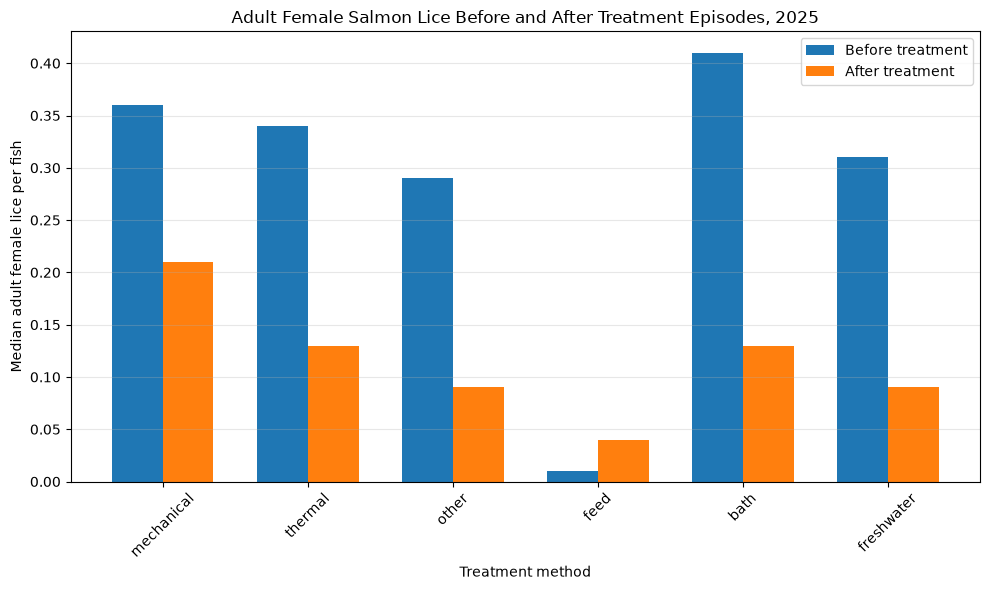

In [52]:
import matplotlib.pyplot as plt
import numpy as np

methods = method_medians.index
pre = method_medians["median_pre"]
post = method_medians["median_post"]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    pre,
    width,
    label="Before treatment"
)

plt.bar(
    x + width/2,
    post,
    width,
    label="After treatment"
)

plt.xticks(
    x,
    methods,
    rotation=45
)

plt.xlabel("Treatment method")
plt.ylabel("Median adult female lice per fish")

plt.title(
    "Adult Female Salmon Lice Before and After Treatment Episodes, 2025"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/day5_treatment_pre_post_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

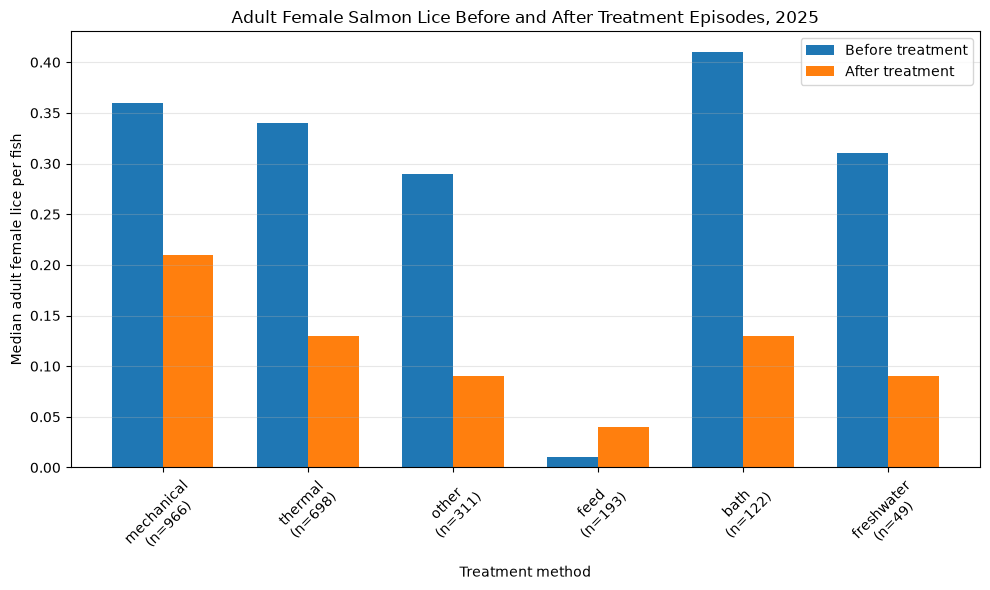

In [53]:
import matplotlib.pyplot as plt
import numpy as np

methods = method_medians.index
pre = method_medians["median_pre"]
post = method_medians["median_post"]
n = method_medians["episodes"]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    pre,
    width,
    label="Before treatment"
)

plt.bar(
    x + width/2,
    post,
    width,
    label="After treatment"
)

# Add sample size under each treatment name
labels = [
    f"{method}\n(n={count})"
    for method, count in zip(methods, n)
]

plt.xticks(
    x,
    labels,
    rotation=45
)

plt.xlabel("Treatment method")
plt.ylabel("Median adult female lice per fish")

plt.title(
    "Adult Female Salmon Lice Before and After Treatment Episodes, 2025"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/day5_treatment_pre_post_median.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Among 2,925 treatment episodes with valid pre- and post-treatment lice measurements, 74.5% were followed by a decrease in adult female lice. In single-method episodes, median lice levels decreased after mechanical, thermal, bath, freshwater, and other treatments. Feed-treatment episodes showed a different pattern, beginning at very low lice levels and increasing over the following weeks. Because treatment assignment was observational and baseline lice levels differed between methods, these results describe post-treatment patterns rather than causal treatment efficacy.